# Exercise 2 — ML Key Challenges


In this exercise, you will train several models and observe three cases:

1. Underfitting — model too simple
2. Good fit — model captures the pattern
3. Overfitting — model memorizes the noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


Create synthetic nonlinear data

In [2]:
np.random.seed(42)

X = np.linspace(0, 10, 80).reshape(-1, 1)

y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.25, size=y_true.shape)


Train / test split

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# For smooth plotting
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

In [4]:
models = [
    {"degree": 1, "name": "Model A"},
    {"degree": 4, "name": "Model B"},
    {"degree": 15, "name": "Model C"},
]

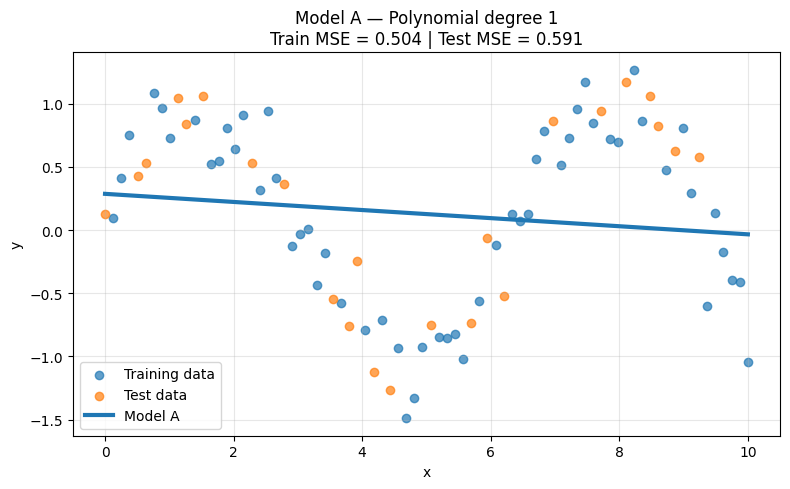

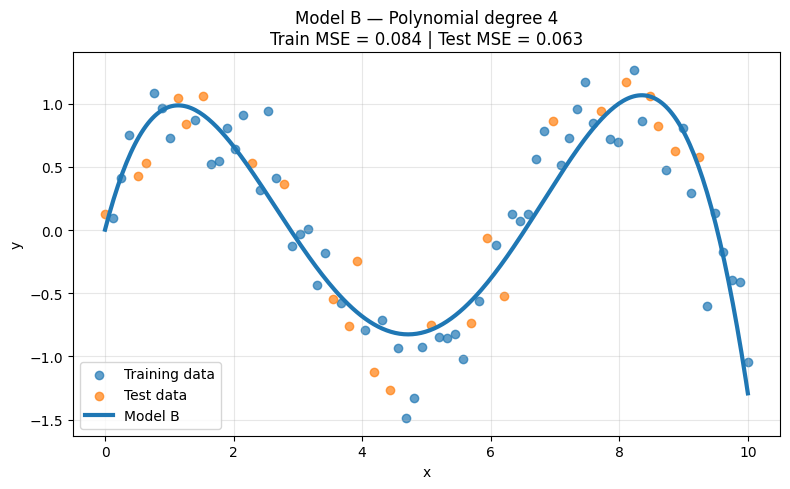

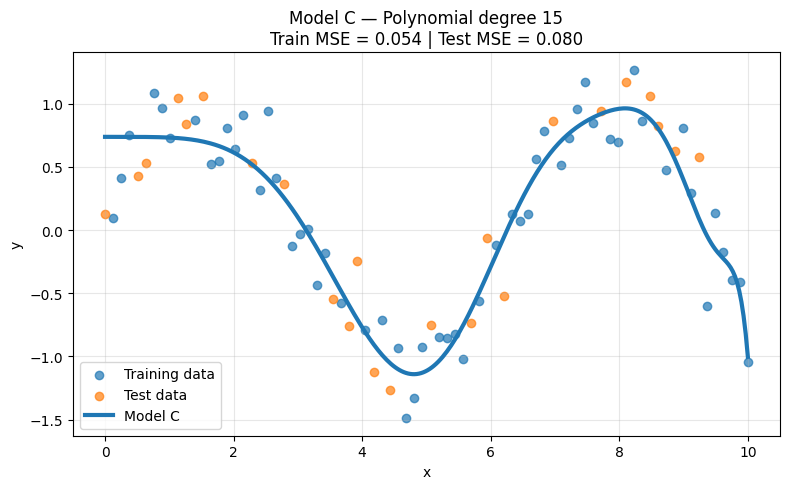

In [5]:
for item in models:
    degree = item["degree"]

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot = model.predict(x_plot)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    plt.figure(figsize=(8, 5))

    plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
    plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
    plt.plot(x_plot, y_plot, linewidth=3, label=item["name"])

    plt.title(
        f"{item['name']} — Polynomial degree {degree}\n"
        f"Train MSE = {train_mse:.3f} | Test MSE = {test_mse:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Questions

1. Which model is underfitting?
- Model A
2. Which model is overfitting?
- Model C
3. Which model generalizes best?
- Model B
4. How do you know from the plot?
- Model A: The model performs poorly on both training and testing data
- Model B: The model performs well on both training and testing data
- Model C: The model performs well on training data but poorly on testing data
5. How do you know from the train/test MSE?
- From the train/test MSE, we can know the accuracy of the predict data with the expected data
- From these 3 plots we can see:
    + Model A's traning MSE and testing MSE both are worst -> A is the underfitting
    + Model B's training MSE and testing MSE both are better -> B is the generalizes best
    + Model C's training MSE is better, however, testing MSE is worst  -> C is the overfitting